## SIGN LANGUAGE DETECTION

**import dependencies**

In [1]:
import tensorflow as tf
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam


**load your dataset**

In [2]:
IMG_SIZE = 64
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   zoom_range=0.2,
                                   shear_range=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    "Dataset/training_set",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    "Dataset/test_set",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle = False
)


Found 45500 images belonging to 26 classes.
Found 6500 images belonging to 26 classes.


In [3]:
print(train_data.class_indices)

{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}


**build the CNN model**

In [4]:
model = Sequential()

# 1️⃣ First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)))
model.add(MaxPooling2D(pool_size=(2,2)))

# 2️⃣ Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 3️⃣ Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

# 4️⃣ Flatten Layer
model.add(Flatten())

# 5️⃣ Fully Connected Layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# 6️⃣ Output Layer (26 letters)
model.add(Dense(26, activation='softmax'))


c:\Users\riyad\sign_language_detection\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**train the model**

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)


model.save("sign_model.keras")

Epoch 1/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 107s 74ms/step - accuracy: 0.8153 - loss: 0.5729 - val_accuracy: 0.9911 - val_loss: 0.0459
Epoch 2/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 87s 61ms/step - accuracy: 0.9429 - loss: 0.1696 - val_accuracy: 0.9905 - val_loss: 0.0221
Epoch 3/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 87s 62ms/step - accuracy: 0.9617 - loss: 0.1151 - val_accuracy: 0.9942 - val_loss: 0.0184
Epoch 4/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - accuracy: 0.9695 - loss: 0.0901 - val_accuracy: 0.9982 - val_loss: 0.0067
Epoch 5/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 91s 64ms/step - accuracy: 0.9767 - loss: 0.0704 - val_accuracy: 0.9945 - val_loss: 0.0145
Epoch 6/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.9799 - loss: 0.0611 - val_accuracy: 0.9980 - val_loss: 0.0071
Epoch 7/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.9836 - loss: 0.0481 - val_accuracy: 0.9991 - val_loss: 0.0051
Epoch 8/15
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 85s 60ms/step - accuracy: 0.9857 

**test on a single image**

In [7]:
import cv2
from tensorflow.keras.models import load_model

model = load_model("sign_model.keras")

img = cv2.imread("1.png")
img = cv2.resize(img, (64,64))
img = img / 255.0
img = np.reshape(img, (1,64,64,3))

prediction = model.predict(img)
print(np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
15


**letter mapping**

In [8]:
classes = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

prediction = model.predict(img)
class_index = np.argmax(prediction)

letter = classes[class_index]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


**detection using opencv**

In [9]:
cap = cv2.VideoCapture(0)

while True:
    ret,frame = cap.read()

    if not ret:
        print("camera not working")
        break

    img = cv2.resize(frame,(64,64))
    img = img/255.0
    img = np.reshape(img,(1,64,64,3))

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    cv2.putText(frame,str(class_index),(10,50),
        cv2.FONT_HERSHEY_SIMPLEX, 1,(0,255,0),2)
    
    cv2.imshow("Sign Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

**accuracy on test data**

In [13]:
test_data.reset()

import sklearn
from sklearn.metrics import classification_report, confusion_matrix

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

print(confusion_matrix(test_data.classes, y_pred))
print(classification_report(test_data.classes, y_pred))

204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step
[[250   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0 250   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0 250   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0 250   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0 250   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0 250   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0 250   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0 237   0   0   0   0   0   0   0   0  13   0
    0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0 250   0   0   0   0   0   0   0   0   0
    0   0   

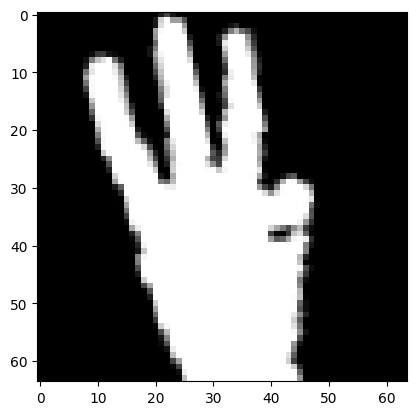

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0.
 0. 0.]


In [14]:
import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.imshow(images[0])
plt.show()
print(labels[0])